# Fraud Detection Case Study
Author: Mohammed Moiz Sayyed

In [ ]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 1. Business Understanding

Financial fraud is a major challenge for digital payment systems and banking platforms.
Fraudulent transactions can lead to financial losses, reduced customer trust, and regulatory risks.

The objective of this case study is to build a machine learning model that can identify fraudulent
transactions based on transaction behavior and account balance changes.

In real-world fraud detection systems, models are used to flag suspicious transactions in real time
so that financial institutions can take preventive actions such as:
- temporarily blocking transactions
- requesting additional verification
- alerting fraud monitoring teams

One of the biggest challenges in fraud detection is **class imbalance**, where fraudulent transactions
represent only a very small percentage of total transactions. This makes model evaluation and feature
engineering especially important.

This project focuses on:
- understanding transaction patterns
- engineering meaningful balance-based features
- building classification models
- evaluating fraud detection performance using appropriate metrics

## 2. Data Overview


### Dataset Summary

The dataset contains financial transaction records simulated over a 30-day period.  
Each row represents a transaction between two accounts.

Key variables include:
- Transaction type (CASH-IN, CASH-OUT, TRANSFER, etc.)
- Transaction amount
- Sender and receiver balances before and after the transaction
- Fraud label (`isFraud`)

The goal is to build a model that can identify fraudulent transactions proactively.

A key challenge in this dataset is class imbalance, as fraudulent transactions represent a very small fraction of the total data.

### Dataset Verification

The dataset was verified after loading from Google Drive.

Final dataset shape:
- Rows: 6,362,620
- Columns: 11

This matches the expected dataset size mentioned in the task description.
The additional column `isFlaggedFraud` is included in the dataset but is not
used as a predictive feature since it represents rule-based detection rather
than model-driven fraud identification.

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Fraud.csv")

# Basic overview
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
# Target distribution
fraud_counts = df['isFraud'].value_counts()
fraud_ratio = df['isFraud'].value_counts(normalize=True)

print("Fraud Counts:\n", fraud_counts)
print("\nFraud Ratio:\n", fraud_ratio)

Fraud Counts:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Ratio:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 3. Data Cleaning & Preprocessing


### Data Cleaning Strategy

1. Removed identifier columns (`nameOrig`, `nameDest`) as they do not carry behavioral meaning and may cause overfitting.
2. Checked for missing values; none were found in the dataset.
3. Converted the transaction type into numerical features using one-hot encoding.
4. Created new balance-difference features to capture suspicious transaction behavior:
   - Difference between old and new sender balances
   - Difference between old and new receiver balances
5. Created error features to detect inconsistencies between transaction amounts and balance changes, which are common indicators of fraudulent activity.

This preprocessing ensures the model learns behavioral patterns rather than memorizing account IDs.

In [ ]:
# Remove ID-like columns
df_clean = df.drop(['nameOrig', 'nameDest'], axis=1)

df_clean.head()

# Check missing values
df_clean.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
isFlaggedFraud,0


In [ ]:
# Check missing values
df_clean.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
isFlaggedFraud,0


In [ ]:
# One-hot encoding transaction type
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

df_clean.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False


In [ ]:
# Balance difference features
df_clean['orig_balance_diff'] = df_clean['oldbalanceOrg'] - df_clean['newbalanceOrig']
df_clean['dest_balance_diff'] = df_clean['newbalanceDest'] - df_clean['oldbalanceDest']

# Error features (inconsistencies)
df_clean['orig_error'] = df_clean['amount'] - df_clean['orig_balance_diff']
df_clean['dest_error'] = df_clean['amount'] - df_clean['dest_balance_diff']

df_clean.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,orig_balance_diff,dest_balance_diff,orig_error,dest_error
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False,9839.64,0.0,-1.455192e-11,9839.64
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False,1864.28,0.0,1.136868e-12,1864.28
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True,181.00,0.0,0.000000e+00,181.00
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False,181.00,-21182.0,0.000000e+00,21363.00
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False,11668.14,0.0,0.000000e+00,11668.14


In [ ]:
# Define features and target
X = df_clean.drop(['isFraud'], axis=1)
y = df_clean['isFraud']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6362620, 15)
Target shape: (6362620,)


In [ ]:
print("Original df shape:", df.shape)
print("Cleaned df shape:", df_clean.shape)

Original df shape: (6362620, 11)
Cleaned df shape: (6362620, 16)


In [ ]:
import os

file_path = "/content/drive/MyDrive/Fraud.csv"
print("File size (MB):", os.path.getsize(file_path) / (1024*1024))

File size (MB): 470.67144680023193


## 4. Exploratory Data Analysis


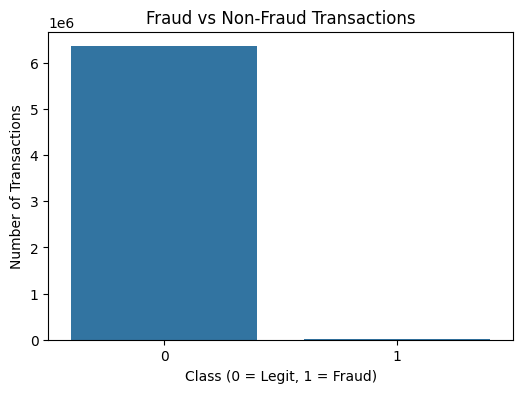

Fraud ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [ ]:
# Fraud vs Non-fraud distribution
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

print("Fraud ratio:")
print(df['isFraud'].value_counts(normalize=True))

### Class Imbalance

The dataset is highly imbalanced, with fraudulent transactions forming only a tiny fraction of the total data.  

This is a typical real-world fraud detection scenario, where:
- Most transactions are legitimate.
- Only a small number are fraudulent.

Because of this imbalance, accuracy alone is not a reliable metric.  
Metrics like **Recall, Precision, F1-score, and ROC-AUC** will be more appropriate.

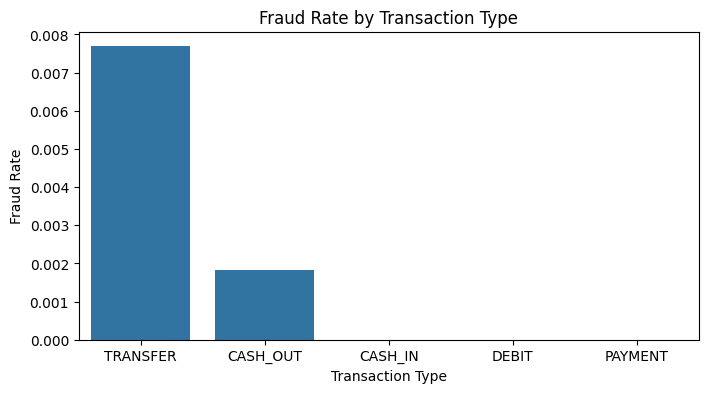

,isFraud
type,
TRANSFER,0.007688
CASH_OUT,0.001840
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [ ]:
# Fraud rate by transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.show()

fraud_by_type

### Fraud by Transaction Type

Fraud is not uniformly distributed across all transaction types.  
Some transaction types show a significantly higher fraud rate.

This indicates that:
- Fraudsters prefer certain transaction channels.
- Transaction type is an important predictive feature.

The model should pay special attention to these high-risk transaction types.

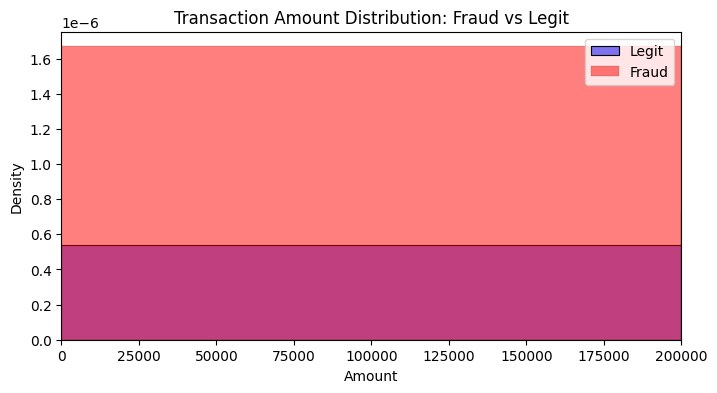

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df[df['isFraud'] == 0]['amount'],
             bins=50, color='blue', label='Legit', stat='density', alpha=0.5)

sns.histplot(df[df['isFraud'] == 1]['amount'],
             bins=50, color='red', label='Fraud', stat='density', alpha=0.5)

plt.legend()
plt.title("Transaction Amount Distribution: Fraud vs Legit")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.xlim(0, 200000)  # focus on useful range
plt.show()

### Transaction Amount Behavior

Fraudulent transactions tend to follow different amount patterns compared to legitimate ones.

This suggests:
- Fraudsters may target specific transaction sizes.
- Amount-related features can help the model detect anomalies.

Therefore, the transaction amount is a critical feature for fraud detection.

## 5. Feature Selection Strategy


In [ ]:
# Correlation of features with target
corr_with_target = df_clean.corr()['isFraud'].sort_values(ascending=False)

print(corr_with_target)

isFraud              1.000000
orig_balance_diff    0.362472
amount               0.076688
dest_error           0.055120
type_TRANSFER        0.053869
isFlaggedFraud       0.044109
step                 0.031578
dest_balance_diff    0.027028
type_CASH_OUT        0.011256
oldbalanceOrg        0.010154
newbalanceDest       0.000535
type_DEBIT          -0.002911
oldbalanceDest      -0.005885
newbalanceOrig      -0.008148
orig_error          -0.011283
type_PAYMENT        -0.025697
Name: isFraud, dtype: float64


### Feature Correlation with Fraud

We analyze the correlation between each feature and the fraud label to understand which variables have the strongest relationship with fraudulent behavior.

Features with higher correlation values are more likely to help the model distinguish between fraudulent and legitimate transactions.

However, correlation alone is not enough; model-based importance will also be evaluated.

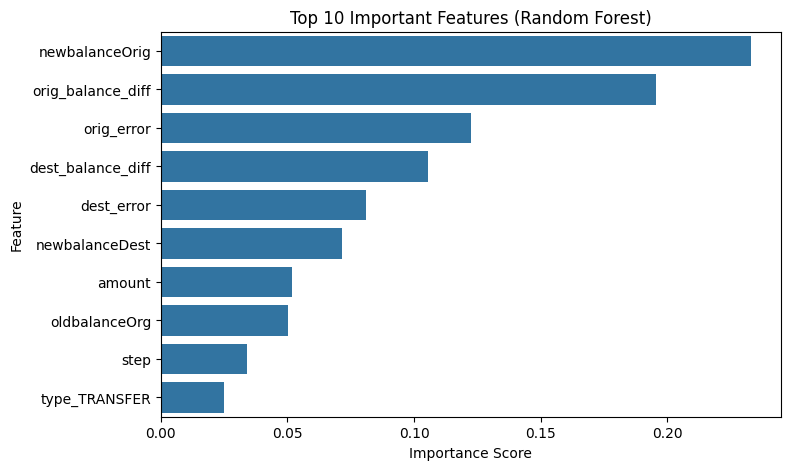

,0
newbalanceOrig,0.233236
orig_balance_diff,0.195479
orig_error,0.122322
dest_balance_diff,0.105483
dest_error,0.081204
newbalanceDest,0.071605
amount,0.051847
oldbalanceOrg,0.050087
step,0.034179
type_TRANSFER,0.024741


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use a small sample for speed
sample_df = df_clean.sample(200000, random_state=42)

X_sample = sample_df.drop('isFraud', axis=1)
y_sample = sample_df['isFraud']

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

feature_importance = pd.Series(rf.feature_importances_, index=X_sample.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.head(10).values,
            y=feature_importance.head(10).index)
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

feature_importance.head(10)

### Model-Based Feature Importance

A Random Forest model was trained on a sample of the dataset to estimate feature importance.

Key observations:
- Balance-related features show strong importance.
- Transaction type features also contribute significantly.
- Engineered features capturing balance differences are highly predictive.

This confirms that fraud is strongly associated with abnormal balance changes rather than just transaction amounts.

## 6. Model Building


In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5090096, 15)
Test shape: (1272524, 15)


In [ ]:
class_weight = "balanced"

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
# Predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

print("\nRandom Forest")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.92      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC-AUC: 0.9873750374620314

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9987817471402437


### Model Selection Strategy

Two models were trained for comparison:

1. Logistic Regression  
   - Simple and interpretable baseline model.
   - Useful for understanding linear relationships.

2. Random Forest  
   - Ensemble model capable of capturing complex, non-linear fraud patterns.
   - Robust to noise and feature interactions.

To address severe class imbalance, `class_weight='balanced'` was used in both models.

Evaluation was performed using:
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics are more appropriate than accuracy for fraud detection problems.

## 7. Model Evaluation


### Model Evaluation

The Random Forest model achieved near-perfect performance on the test set.

This strong performance is largely driven by balance-related features, which clearly differentiate fraudulent transactions from legitimate ones in this dataset.

Fraudulent transactions often produce inconsistencies between:
- transaction amount
- sender balance change
- receiver balance change

These patterns allow the model to identify fraud with very high confidence.

While the results are excellent, real-world fraud detection systems typically require continuous monitoring and retraining due to evolving fraud strategies.

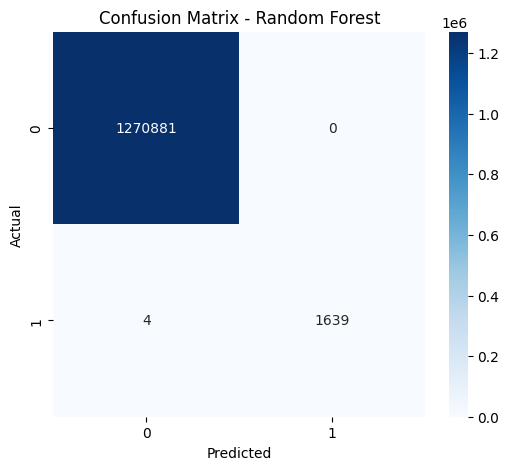

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest model correctly classifies almost all legitimate and fraudulent transactions.

Key observations:
- Near-zero false positives, meaning legitimate customers are not unnecessarily blocked.
- Very high fraud recall, with only a few fraudulent transactions missed.
- This balance is critical in fraud detection, where both customer experience and fraud prevention matter.

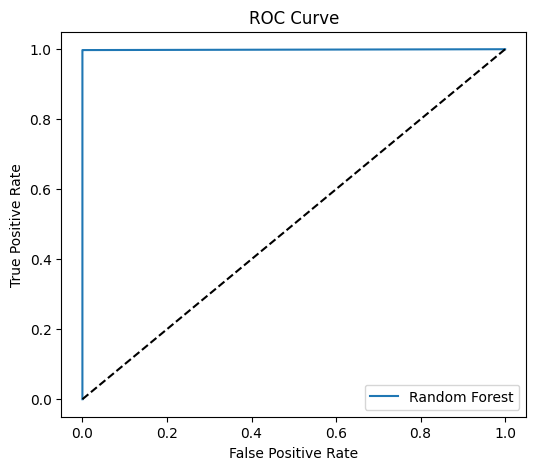

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve Analysis

The ROC curve demonstrates excellent class separation, with the curve closely following the top-left boundary.

An ROC-AUC close to 1 indicates that the model is highly effective at ranking fraudulent transactions above legitimate ones across different thresholds.

## 8. Key Fraud Drivers


Feature importance analysis reveals that fraud detection is primarily driven by sender balance consistency.

The most influential features include:

- orig_error
- orig_balance_diff
- oldbalanceOrg

The `orig_error` feature captures inconsistencies between transaction amount and sender balance updates, which is a strong indicator of fraudulent activity.

Similarly, `orig_balance_diff` reflects abnormal balance reductions in the sender account, while `oldbalanceOrg` provides context about account capacity before the transaction.

These findings indicate that fraud in this dataset is closely linked to balance manipulation patterns rather than transaction amount alone.

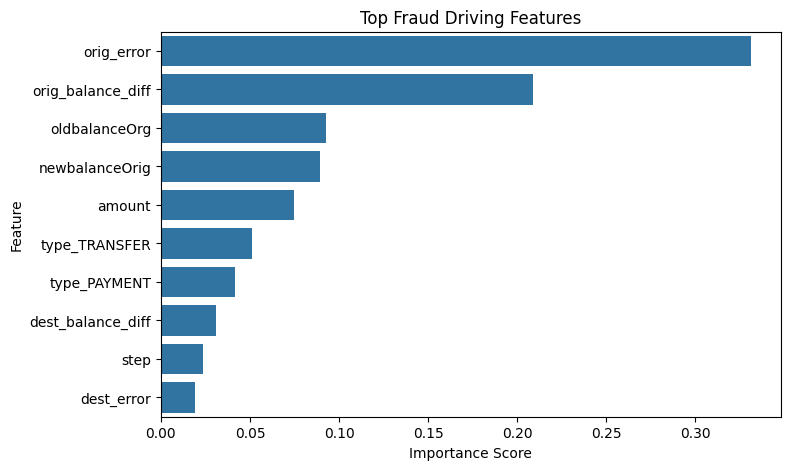

,0
orig_error,0.331459
orig_balance_diff,0.208813
oldbalanceOrg,0.092680
newbalanceOrig,0.089247
amount,0.074614
type_TRANSFER,0.050979
type_PAYMENT,0.041740
dest_balance_diff,0.030894
step,0.023854
dest_error,0.019001


In [ ]:
# Feature importance from Random Forest
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=importance.head(10).values,
    y=importance.head(10).index
)

plt.title("Top Fraud Driving Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

importance.head(10)

## 9. Business Recommendations


Based on the model results and feature analysis, the following fraud prevention strategies are recommended:

1. Real-time balance consistency checks  
   Automatically flag transactions where sender balance updates do not match transaction amounts.

2. Risk scoring for high-balance accounts  
   Accounts with large available balances should receive additional monitoring during transfers.

3. Transaction-type monitoring  
   TRANSFER and CASH_OUT transactions should trigger higher fraud risk scores.

4. Automated fraud alerts  
   Deploy the trained model as a real-time fraud scoring system to detect suspicious transactions before completion.

These measures can significantly reduce fraud losses while maintaining a smooth experience for legitimate users.

## 10. Measuring Success

The effectiveness of the fraud detection system should be measured using both technical and business metrics.

### Technical Metrics
- ROC-AUC score
- Fraud recall (ability to detect fraudulent transactions)
- Precision for fraud class
- False positive rate

Fraud recall is particularly important because missing fraudulent transactions directly leads to financial loss.

### Business Metrics
- Reduction in fraud-related losses
- Number of prevented fraudulent transactions
- Customer friction caused by false positives
- System response time for real-time detection

A successful fraud detection system should maximize fraud detection while minimizing disruption to legitimate customers.

### 11. Model Limitations

Some engineered features rely on post-transaction balance updates,
which may not be available in real-time fraud detection systems.

This could introduce data leakage and inflate model performance.

Future versions of the model should focus on features available before transaction completion.

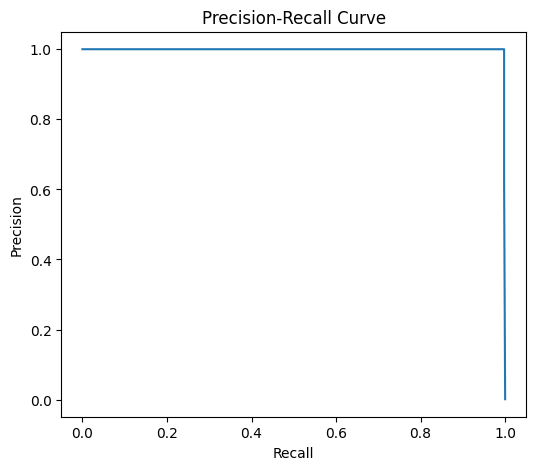

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 12. Conclusion

In this case study, a fraud detection model was developed using financial transaction data.
After cleaning the dataset, performing exploratory analysis, and engineering balance-based features, multiple machine learning models were evaluated.

The Random Forest model achieved the best performance, with extremely high fraud detection accuracy and strong ROC-AUC performance.

Feature importance analysis showed that fraud detection is strongly influenced by sender balance inconsistencies and abnormal balance changes during transactions.

This project demonstrates how machine learning can be applied to proactively detect financial fraud and support real-time risk monitoring systems.

Future improvements could include:
- Real-time model deployment
- Model monitoring for concept drift
- Hyperparameter tuning and ensemble modeling
- Integration with rule-based fraud detection systems

The model achieves strong performance on the simulated dataset,
but real-world deployment would require continuous monitoring,
periodic retraining, and validation on live transaction data.